📅 **论文年份 (Year):2023 年**
*Visual Instruction Tuning (LLaVA) — Liu, Li, Wu, Lee — NeurIPS 2023 (Oral)*

# Bonus Paper 34: LLaVA(视觉指令微调)
## Liu et al., University of Wisconsin-Madison / Microsoft Research(刘浩天等)

### Implementation: Toy LLaVA — Visual Tokens + Two-Stage Instruction Tuning(实现：视觉 token 注入 + 两阶段指令微调的玩具版 LLaVA)

This notebook implements the core recipe of LLaVA using only NumPy: encode an image into patch features, pass them through **a single linear projection** to get "visual tokens", insert them into the input sequence of a tiny autoregressive transformer LM (hand-written backprop), and follow LLaVA's **two-stage training**: Stage 1 aligns the projection with the LM frozen; Stage 2 instruction-tunes projection + LM on (image, instruction, answer) triples.

本笔记本只用 NumPy 实现 LLaVA 的核心配方：图像编码成 patch 特征,经**一个线性投影层**变成"视觉 token"插入微型自回归 Transformer LM(手写反向传播)的输入序列;然后复现 LLaVA 的**两阶段训练**——Stage 1 冻结 LM 只训投影做对齐,Stage 2 用(图像,指令,回答)三元组把投影和 LM 一起微调,让模型"看图听话":问颜色答颜色、问形状答形状、问数量答数量。

> 注:LLaVA 不在 Sutskever 原始 30 篇书单中,是本仓库的多模态扩展(Bonus)。它与 CLIP(Bonus 31)一起构成现代开源多模态助手(视觉语言模型 VLM)的标准蓝图。

## 📖 论文导读

**🎯 这篇文章想解决什么问题(目的):** 2023 年初,指令微调已经让纯文本 LLM 学会"听懂人话"(InstructGPT、Vicuna),但视觉世界还没有对应的开源方案:CLIP 能对齐图文却不会对话,GPT-4V 闭源且细节未公开。核心难题有两个——(1) 没有"图像+指令+回答"格式的训练数据;(2) 怎样把一个预训练视觉编码器和一个预训练 LLM 拼成一个能端到端对话的整体,而不破坏两者各自学到的能力。

**💡 主要贡献:** LLaVA 给出了一个惊人简洁的答案:(1) **数据**——用纯文本 GPT-4 把图像的字幕和物体框"翻译"成 158K 条多模态指令数据(对话、详细描述、复杂推理三类),开创了"用强 LLM 合成多模态训练数据"的范式;(2) **架构**——CLIP 视觉编码器与 Vicuna LLM 之间只用**一个线性投影矩阵 W** 连接,把视觉特征直接变成"视觉 token"插进 LM 的输入序列;(3) **两阶段训练**——先在 595K 图文对上冻结两端只训 W(特征对齐),再在 158K 指令数据上微调 W+LLM(指令跟随)。最终 LLaVA 在多模态对话上达到 GPT-4 相对分数 85.1%,并在 Science QA 上与 GPT-4 协同刷新 SOTA(92.53%)。

**🔧 方法:** 图像 X_v 经冻结的 CLIP 编码器得到网格特征 Z_v,视觉 token H_v = W·Z_v 与文本嵌入拼接成一个序列输入 LLM,训练目标是标准的自回归下一词预测,**损失只算在回答部分**(指令部分被掩掉)。本笔记本按同样配方缩小一千倍:合成图形(1-2 个彩色几何形状)→ 共享 MLP 逐 patch 编码(扮演 CLIP,监督预训练后冻结)→ 线性投影成 4 个视觉 token → 2 层因果 Transformer LM;Stage 0 先用纯文本预训练 LM(扮演 Vicuna),Stage 1 只训投影,Stage 2 指令微调,全部手写反向传播。

**🌟 意义:** LLaVA 证明了"多模态能力不需要重新发明架构":两个各自预训练好的单模态模型,中间垫一个线性层、再喂对格式的指令数据,就能变成视觉对话助手。这个"visual token + 两阶段"配方成为其后几乎所有开源 VLM(LLaVA-1.5/NeXT、Qwen-VL、InternVL、MiniGPT-4 等)的骨架;"用 GPT-4 合成指令数据"则成为多模态数据工程的标准操作。理解 LLaVA,就理解了今天任何一个"能看图的 ChatGPT"的内部结构。

## 🎯 核心结论 (Key Takeaways)

- **一个线性层就是全部的"桥"。** 视觉端到语言端的全部连接只有 3,120 个参数(64→48 的线性投影),不到 LM 参数量(40,925)的 8%。完整两阶段训练后,模型对三类指令的回答准确率:颜色 **99.7%**、形状 **93.3%**、数量 **98.7%**,全部 ≥93%。桥能这么小,是因为视觉编码器和 LM 都已各自"会说自己的语言",桥只需做线性翻译。

- **两阶段各干各的活,缺一不可。** Stage 1(冻结 LM,只训投影,描述任务)把损失从 ~2.1 降到 ~0.45——视觉信息接上了;Stage 2(投影+LM 一起指令微调)把损失进一步压到 ~0.03——模型学会"听话"。只做 Stage 1 的基线模型问什么都答描述:形状问题准确率仅 **1.7%**,颜色 31.3%,而完整模型分别是 93.3% 和 99.7%。

- **"会看"不等于"听话",指令数据才买来听话。** Stage-1 基线的回答里其实**包含**正确信息(数量词命中率 92.3%,颜色词 66.3%)——它看得见,只是无视问题、按预训练格式自说自话。指令微调不是教模型"看",而是教它"按问题选择性地说"。

- **损失下限暴露了信息的来源。** Stage 0 纯文本预训练损失停在 **0.583**,与理论下限 0.578(答案内容在没有图像时不可预测,只剩格式可学:¼·(ln2+2ln3) + ½·ln3 + ¼·ln2 除以平均 2.5 个 token)几乎重合;Stage 1 一接入图像,损失立刻跌破这条线——**损失跌破纯文本下限的那一刻,就是视觉信息开始流入语言模型的时刻**。

- **注意力给出机制证据。** 回答问题的那个位置,第 2 层注意力把 ≈100% 的权重投向 4 个视觉 token(而非指令文本),且注意力分布随问题变化:颜色/数量问题锁定单个含物体的 patch(0.98 / 1.00),形状问题把权重分摊到两个含物体的 patch(0.57 / 0.43)——模型确实在"看图回答",而不是在背指令-答案的统计规律。

- **防遗忘是设计动机:** LLaVA 的 158K 指令数据专门保留"详细描述"类别,以防指令微调丢掉描述能力;本 notebook 照做(Stage 2 混入 25% 描述任务),完整模型描述准确率 92.0%。注意 92.0% vs 56.7% 是完整模型 vs Stage1-only 的对比,本文未运行"去掉描述数据"的消融,遗忘是否发生留作练习。

## 🤯 反常识的发现 (Counterintuitive Findings)

- **常识认为:连接视觉模型和语言模型需要精巧的融合架构(交叉注意力、Q-Former、门控…)。** LLaVA 用一个线性矩阵乘法就完成了连接,本实验中这个桥只有 3,120 参数(整个系统 11 万参数的 3%),三类指令准确率仍全部 ≥93%。两个预训练模型就像两个各自精通母语的人,中间只缺一本"词典",而词典可以是线性的。

- **常识认为:Stage 1 对齐之后,模型已经"看得懂图",任务就完成了。** 基线实验(跳过 Stage 2)戳破了这个想象:它确实看得懂——描述里数量词命中 92.3%——但你问"什么形状",它答"two green"(接着背描述),形状问题准确率 1.7%。**感知与服从是两种独立的能力**,后者只能靠指令数据买到。

- **常识认为:冻结的网络什么也学不了。** Stage 1 里 LM 一个参数都不动,仅靠调 3,120 个投影参数,冻结的 LM 就能输出 56.7% 完全正确的图像描述——投影学会了把视觉特征"伪装"成 LM 期待的前缀输入(与 prefix-tuning 同理)。梯度可以穿过冻结的参数,去指挥可训练的输入。

- **常识认为:损失不再下降=训练失败。** Stage 0 的损失死死卡在 0.583,看似失败,实为必然:纯文本预训练时答案内容(哪种颜色/形状/数量)原理上不可预测,0.578 是信息论下限,LM 已把"能学的格式"学完了。判断训练好坏要先算清**下限在哪里**——这与 Bonus 31(CLIP)中重复标题造成 ln(8) 下限如出一辙。

#### 💻 代码解读

**做什么:** 导入依赖并固定随机种子,保证实验可复现。

**怎么做:**
- 只用 `numpy`(数值计算)和 `matplotlib`(画图),与本仓库其他 notebook 保持一致——不依赖任何深度学习框架。
- `deepcopy` 用于在 Stage 2 开始前快照"只做过 Stage 1"的模型,作为消融基线。
- 固定两个随机源:全局 `np.random.seed` 和新式 `default_rng`;数据生成、参数初始化、采样全走 `rng`,结果完全可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

np.random.seed(42)
# 新式随机数生成器:数据、初始化、采样都用它,保证可复现
rng = np.random.default_rng(0)

## Synthetic Image-Instruction Dataset(合成"图像-指令-回答"数据集)

#### 💻 代码解读

**做什么:** 构造带三种可问属性的合成图像:每张 20×20 的图里有 **1 或 2 个**同色同形的几何图形,属性为(颜色 3 种 × 形状 3 种 × 数量 2 种)= 18 个概念组合;并把图像切成 2×2 共 4 个 patch,对应 LLaVA 中 CLIP 输出的特征网格。

**怎么做:**
- `draw_shape`:用 `np.mgrid` 生成全部像素坐标,再用布尔掩码一次性上色(圆=距离方程、方=切比雪夫距离、三角=半平面交集),NumPy 向量化画图技巧,与 Bonus 31 一致。
- `draw_scene`:数量为 1 时图形随机位于中部;数量为 2 时分居左右两侧,位置/大小均随机抖动——迫使编码器学概念而非死记像素。
- `to_patches`:把 (20,20,3) 图像切成 4 个 10×10×3=300 维的 patch 向量,**每个 patch 之后会变成一个视觉 token**——这正是 LLaVA/ViT "一个 patch 一个 token" 的缩小版。
- 示例图用独立的 `rng_fig`,不消耗主随机流,保证后续训练完全可复现。

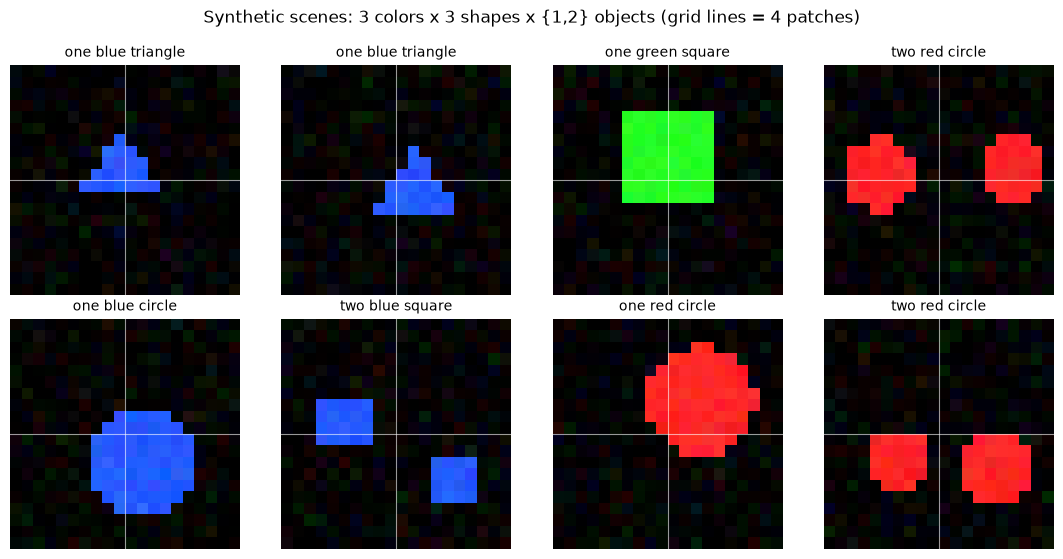

In [2]:
# 3色 × 3形 × {1,2}个 = 18种场景;每张图内所有图形同色同形,保证问答无歧义
COLORS = {'red': (1.0, 0.15, 0.15), 'green': (0.15, 1.0, 0.15), 'blue': (0.15, 0.35, 1.0)}
SHAPES = ['circle', 'square', 'triangle']
NUMW = {1: 'one', 2: 'two'}  # 数量词
IMG = 20  # 图像尺寸 20x20x3

def draw_shape(img, color, shape, cx, cy, r, rng):
    """Paint one shape onto img at center (cx,cy) with size r (in-place)"""
    # np.mgrid一次生成所有像素坐标网格;布尔掩码向量化选中图形内像素
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    if shape == 'circle':
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    elif shape == 'square':
        mask = (np.abs(xx - cx) <= r * 0.8) & (np.abs(yy - cy) <= r * 0.8)
    else:  # triangle:顶点在上,三条边的半平面交集
        mask = (yy - (cy - r) >= 0) & (yy - (cy - r) <= 1.5 * r) & \
               (np.abs(xx - cx) <= (yy - (cy - r)) / 1.5)
    img[mask] = COLORS[color]

def draw_scene(color, shape, count, rng):
    """Draw a scene with 1 or 2 identical shapes, with jitter and noise"""
    img = np.zeros((IMG, IMG, 3)) + rng.normal(0, 0.04, (IMG, IMG, 3))
    if count == 1:
        cx, cy = rng.uniform(6.0, 14.0, 2)
        r = rng.uniform(3.5, 5.0)
        draw_shape(img, color, shape, cx, cy, r, rng)
    else:
        # 两个图形分居左右两侧,避免重叠,数量特征清晰
        cy1, cy2 = rng.uniform(5.5, 14.5, 2)
        r1, r2 = rng.uniform(2.6, 3.6, 2)
        draw_shape(img, color, shape, rng.uniform(4.0, 6.0), cy1, r1, rng)
        draw_shape(img, color, shape, rng.uniform(14.0, 16.0), cy2, r2, rng)
    img += rng.normal(0, 0.03, img.shape)
    return np.clip(img, 0, 1)

def to_patches(img):
    """(20,20,3) -> 4 patches of 10x10x3 = 300 dims each (2x2 grid)"""
    # 一个patch将对应一个视觉token:LLaVA/ViT"逐patch成token"的缩小版
    ps = []
    h = IMG // 2
    for i in range(2):
        for j in range(2):
            ps.append(img[i*h:(i+1)*h, j*h:(j+1)*h].reshape(-1))
    return np.array(ps)

def make_scenes(n, rng):
    """Generate n scenes; returns patches (n,4,300) and attribute list"""
    attrs, X = [], []
    for _ in range(n):
        c = list(COLORS)[rng.integers(3)]
        s = SHAPES[rng.integers(3)]
        k = int(rng.integers(1, 3))
        attrs.append((c, s, k))
        X.append(to_patches(draw_scene(c, s, k, rng)))
    return np.array(X), attrs

# 示例图用独立随机流rng_fig:不动主rng,保证后面训练可复现
rng_fig = np.random.default_rng(5)
fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for ax in axes.flat:
    c = list(COLORS)[rng_fig.integers(3)]
    s = SHAPES[rng_fig.integers(3)]
    k = int(rng_fig.integers(1, 3))
    ax.imshow(draw_scene(c, s, k, rng_fig))
    ax.set_title(f'{NUMW[k]} {c} {s}', fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic scenes: 3 colors x 3 shapes x {1,2} objects (grid lines = 4 patches)', y=0.99)
for ax in axes.flat:
    # 画出2x2 patch分界线:每个patch即将成为一个视觉token
    ax.axhline(IMG/2 - 0.5, color='white', lw=0.8, alpha=0.6)
    ax.axvline(IMG/2 - 0.5, color='white', lw=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## Vocabulary, Instruction Templates & Sequence Packing(词表、指令模板与序列打包)

#### 💻 代码解读

**做什么:** 定义 29 词的小词表、三类指令(每类 3 个模板,共 9 个)+ 1 个描述指令,以及把(指令,回答)打包成训练批次的函数——**损失只算在回答 token 上**,这正是 LLaVA 的做法。

**怎么做:**
- 指令类型:`color` → 答颜色词、`shape` → 答形状词、`count` → 答数量词;每类多个措辞不同的模板,**模板多样性决定模型学到的是"问题类型→答案类别"的语义映射,而非死记某句话**。
- 描述指令 "describe the image" → 回答三词描述 "{数量} {颜色} {形状}",用于 Stage 1 对齐(对应 LLaVA 的 595K 图文对)。
- `build_batch`:序列格式为 `[4个视觉token] <bos> 指令词… 回答词… <eos>`,变长序列用 `<pad>` 补齐(pad 在尾部,因果掩码保证它不影响前面);目标 `Y` 与掩码 `M` 只在"预测回答词和 `<eos>`"的位置为 1——指令部分不计损失(LLaVA 论文式 (2) 的 mask)。

In [3]:
VOCAB = ['<pad>', '<bos>', '<eos>',
         'describe', 'the', 'image', 'what', 'color', 'is', 'shape', 'which', 'it',
         'tell', 'how', 'many', 'shapes', 'are', 'there', 'count', 'number', 'in',
         'one', 'two', 'red', 'green', 'blue', 'circle', 'square', 'triangle']
W2I = {w: i for i, w in enumerate(VOCAB)}
V = len(VOCAB)
BOS, EOS = W2I['<bos>'], W2I['<eos>']

# 每类指令3个措辞不同的模板:多样性让模型学"问题类型",而不是背句子
TEMPLATES = {
    'color': [['what', 'color', 'is', 'the', 'shape'], ['which', 'color', 'is', 'it'], ['tell', 'the', 'color']],
    'shape': [['what', 'shape', 'is', 'it'], ['which', 'shape', 'is', 'in', 'the', 'image'], ['tell', 'the', 'shape']],
    'count': [['how', 'many', 'shapes', 'are', 'there'], ['count', 'the', 'shapes'], ['tell', 'the', 'number']],
}
DESCRIBE = ['describe', 'the', 'image']  # Stage 1 对齐用的描述指令
QTYPES = ['color', 'shape', 'count']

def caption_of(c, s, k):
    """Ground-truth description: '{count} {color} {shape}'"""
    return [NUMW[k], c, s]

def answer_of(qtype, c, s, k):
    """Single-word ground-truth answer for each instruction type"""
    return {'color': [c], 'shape': [s], 'count': [NUMW[k]]}[qtype]

NVIS = 4  # 视觉token数 = patch数

def build_batch(items, P):
    """Pack (instruction, answer) pairs into padded X with targets Y and loss mask M.
    P = number of visual prefix tokens. Loss is only on answer tokens + <eos>."""
    seqs = [[BOS] + [W2I[w] for w in ins] + [W2I[w] for w in a] + [EOS] for ins, a in items]
    L = max(len(s) for s in seqs)
    B = len(seqs)
    X = np.zeros((B, L), dtype=int)  # pad=0在尾部;因果掩码保证pad不影响前文
    T = P + L
    Y = np.zeros((B, T), dtype=int)
    M = np.zeros((B, T))
    for i, (s, (ins, a)) in enumerate(zip(seqs, items)):
        X[i, :len(s)] = s
        # 完整序列位置j预测文本token X[j+1-P];只在答案+<eos>处开损失掩码
        ans_start = 1 + len(ins)
        for xj in range(ans_start, len(s)):
            Y[i, P + xj - 1] = s[xj]
            M[i, P + xj - 1] = 1
    return X, Y, M

# 演示一条打包好的训练样本
X_demo, Y_demo, M_demo = build_batch([(TEMPLATES['color'][0], ['red'])], NVIS)
print('sequence :', '[v1 v2 v3 v4]', ' '.join(VOCAB[t] for t in X_demo[0]))
print('loss mask:', M_demo[0].astype(int), ' (1 = predict answer/eos here)')
print(f'vocab size = {V}, instruction templates = {sum(len(v) for v in TEMPLATES.values())} + describe')

sequence : [v1 v2 v3 v4] <bos> what color is the shape red <eos>
loss mask: [0 0 0 0 0 0 0 0 0 1 1 0]  (1 = predict answer/eos here)
vocab size = 29, instruction templates = 9 + describe


## Tiny Autoregressive Transformer LM(微型自回归 Transformer LM,手写前向传播)

#### 💻 代码解读

**做什么:** 实现一个 2 层、单头、48 维的因果 Transformer LM 的前向传播——它扮演 LLaVA 中 Vicuna 的角色。**视觉 token 以"嵌入序列前缀"的形式直接拼进输入**,这一行 `np.concatenate([vis, Emb[X]])` 就是 LLaVA 架构的全部精髓。

**怎么做:**
- `lm_forward` 接收 `vis (B,P,D)`(投影后的视觉 token)和 `X (B,L)`(文本 token id):文本查嵌入表、视觉 token 直接拼在前面、加可学习位置嵌入——**对 LM 来说视觉 token 就是几个"说不出来但看得见"的词**。
- 因果掩码:`np.triu(-1e9, k=1)` 把上三角(未来位置)加上 −10⁹,softmax 后≈0,保证自回归性质;视觉 token 在最前,所有文本位置都能"看到"它们。
- 每层 = 单头自注意力(Q·Kᵀ/√D → softmax → 加权和 V → 输出投影)+ 两层 ReLU MLP,均带残差连接;规模够小,省去 LayerNorm 以简化手写反向传播。
- `cache` 保存所有中间量,供下一个 cell 的反向传播使用。

In [4]:
D = 48    # LM隐层维度
FF = 96   # MLP中间层
NL = 2    # 层数
LMAX = 20 # 最大序列长度(4视觉+1bos+最长指令6+回答3+eos=15 < 20)

def init_lm(rng):
    """Init a 2-layer causal transformer LM (no LayerNorm, small init)"""
    p = {'Emb': rng.normal(0, 0.08, (V, D)), 'Pos': rng.normal(0, 0.08, (LMAX, D)),
         'Wout': rng.normal(0, 0.08, (D, V)), 'bout': np.zeros(V)}
    for l in range(NL):
        for k in ['Wq', 'Wk', 'Wv', 'Wo']:
            p[f'{l}{k}'] = rng.normal(0, 0.08, (D, D))
        p[f'{l}W1'] = rng.normal(0, np.sqrt(2 / D), (D, FF))
        p[f'{l}b1'] = np.zeros(FF)
        p[f'{l}W2'] = rng.normal(0, 0.08, (FF, D))
        p[f'{l}b2'] = np.zeros(D)
    return p

def softmax(S):
    # 数值稳定:先减去最后一维最大值再exp,防溢出
    S = S - S.max(-1, keepdims=True)
    e = np.exp(S)
    return e / e.sum(-1, keepdims=True)

def lm_forward(p, vis, X):
    """vis: (B,P,D) visual token embeddings (P may be 0); X: (B,L) token ids"""
    B, L = X.shape
    P = vis.shape[1]
    T = P + L
    # === LLaVA架构的核心一行:视觉token与词嵌入直接拼成一个序列 ===
    E = np.concatenate([vis, p['Emb'][X]], axis=1) + p['Pos'][:T]
    # 因果掩码:上三角置-1e9,softmax后未来位置权重≈0
    mask = np.triu(np.full((T, T), -1e9), 1)
    caches = []
    H = E
    for l in range(NL):
        Q = H @ p[f'{l}Wq']; K = H @ p[f'{l}Wk']; Vv = H @ p[f'{l}Wv']
        # (B,T,D)@(B,D,T)->(B,T,T)相似度矩阵;/sqrt(D)防止点积过大压扁softmax梯度
        S = Q @ K.transpose(0, 2, 1) / np.sqrt(D) + mask
        A = softmax(S)
        AV = A @ Vv
        O = AV @ p[f'{l}Wo']
        H1 = H + O                       # 残差连接1:注意力
        Uin = H1 @ p[f'{l}W1'] + p[f'{l}b1']
        U = np.maximum(Uin, 0)
        H2 = H1 + U @ p[f'{l}W2'] + p[f'{l}b2']  # 残差连接2:MLP
        caches.append((H, Q, K, Vv, A, AV, H1, Uin, U))
        H = H2
    logits = H @ p['Wout'] + p['bout']
    return logits, (X, P, caches, H)

lm_probe = init_lm(np.random.default_rng(99))  # 探针:仅统计参数量,不参与训练
n_lm = sum(v.size for v in lm_probe.values())
print(f'LM params: {n_lm:,}  (playing the role of Vicuna-13B, scaled down ~300,000x)')

LM params: 40,925  (playing the role of Vicuna-13B, scaled down ~300,000x)


#### 💻 代码解读

**做什么:** 手写整个 Transformer 的反向传播、掩码交叉熵损失和 Adam 优化器——链式法则逐层回传,最终**同时给出 LM 参数梯度和视觉 token 的梯度 `dvis`**,后者是训练投影层的通道。

**怎么做:**
- `lm_backward` 按前向的逆序回传:输出层 → 每层的 MLP(ReLU 梯度 = 正区通行)→ 注意力。注意力最精妙处是**穿过 softmax 的梯度**:`dS = A ⊙ (dA − Σ(dA⊙A))`,即"减去按注意力加权的均值",被掩掉的位置因 A=0 自动得 0 梯度。
- 残差连接的梯度 = 直通支路 + 变换支路两路相加,这是深层网络能训动的关键(Paper 10 ResNet 的核心)。
- `dvis = dH[:, :P]`:回传到嵌入层后,序列前 P 个位置的梯度就是视觉 token 的梯度——Stage 1 里 LM 参数冻结不更新,但**梯度照样穿过冻结的 LM 流到投影层**。
- `ce_loss`:掩码交叉熵,`dlogits = (softmax − one-hot)·M/n`,只有回答位置产生梯度。
- `adam_update` 支持 `keys` 参数:Stage 1 只更新投影的键,Stage 2 更新全部——两阶段的"冻结/解冻"就靠它切换。

In [5]:
def lm_backward(p, cache, dlogits):
    """Manual backprop through the transformer. Returns (param grads, grad wrt visual tokens)."""
    X, P, caches, Hf = cache
    g = {}
    g['Wout'] = np.einsum('btd,btv->dv', Hf, dlogits)
    g['bout'] = dlogits.sum((0, 1))
    dH = dlogits @ p['Wout'].T
    for l in reversed(range(NL)):
        H, Q, K, Vv, A, AV, H1, Uin, U = caches[l]
        # --- MLP残差支路: H2 = H1 + relu(H1 W1+b1) W2+b2 ---
        dM = dH
        dU = dM @ p[f'{l}W2'].T
        g[f'{l}W2'] = np.einsum('btf,btd->fd', U, dM)
        g[f'{l}b2'] = dM.sum((0, 1))
        dUin = dU * (Uin > 0)          # ReLU梯度:正区通行,负区截断
        g[f'{l}W1'] = np.einsum('btd,btf->df', H1, dUin)
        g[f'{l}b1'] = dUin.sum((0, 1))
        dH1 = dH + dUin @ p[f'{l}W1'].T  # 残差:直通+变换两路相加
        # --- 注意力残差支路: H1 = H + (A Vv) Wo ---
        dO = dH1
        g[f'{l}Wo'] = np.einsum('btd,bte->de', AV, dO)
        dAV = dO @ p[f'{l}Wo'].T
        dA = dAV @ Vv.transpose(0, 2, 1)
        dVv = A.transpose(0, 2, 1) @ dAV
        # 穿过softmax的梯度:A⊙(dA-加权均值);掩码位置A=0自动得0梯度
        dS = A * (dA - (dA * A).sum(-1, keepdims=True)) / np.sqrt(D)
        dQ = dS @ K
        dK = dS.transpose(0, 2, 1) @ Q
        g[f'{l}Wq'] = np.einsum('btd,bte->de', H, dQ)
        g[f'{l}Wk'] = np.einsum('btd,bte->de', H, dK)
        g[f'{l}Wv'] = np.einsum('btd,bte->de', H, dVv)
        dH = dH1 + dQ @ p[f'{l}Wq'].T + dK @ p[f'{l}Wk'].T + dVv @ p[f'{l}Wv'].T
    T = dH.shape[1]
    g['Pos'] = np.zeros_like(p['Pos'])
    g['Pos'][:T] = dH.sum(0)
    g['Emb'] = np.zeros_like(p['Emb'])
    # 同一token可能出现多次:np.add.at做无冲突累加(花式索引+=会漏加)
    np.add.at(g['Emb'], X, dH[:, P:])
    # 序列前P个位置的梯度=视觉token的梯度:这是训练投影层的唯一通道
    dvis = dH[:, :P]
    return g, dvis

def ce_loss(logits, Y, M):
    """Masked cross-entropy: loss only where M==1 (answer tokens + eos)"""
    Pm = softmax(logits)
    b, t = np.where(M)
    n = len(b)
    loss = -np.log(Pm[b, t, Y[b, t]] + 1e-12).mean()
    # 交叉熵对logits的梯度 = softmax - one-hot,再乘掩码、除样本数
    dlog = Pm.copy()
    dlog[b, t, Y[b, t]] -= 1
    dlog *= (M[..., None] / n)
    return loss, dlog

def adam_update(p, g, m, v, t, lr, keys=None):
    """Adam with bias correction; `keys` restricts which params get updated (freezing)"""
    for k in (keys if keys is not None else g):
        m[k] = 0.9 * m[k] + 0.1 * g[k]
        v[k] = 0.999 * v[k] + 0.001 * g[k] ** 2
        # 偏差修正:除以(1-beta^t),抵消动量初始为0的低估
        mh = m[k] / (1 - 0.9 ** t)
        vh = v[k] / (1 - 0.999 ** t)
        p[k] -= lr * mh / (np.sqrt(vh) + 1e-8)

print('Backprop, masked CE loss, and Adam ready.')

Backprop, masked CE loss, and Adam ready.


## Vision Encoder: Pretrain then Freeze(视觉编码器:预训练后冻结,扮演 CLIP 的角色)

#### 💻 代码解读

**做什么:** 训练一个逐 patch 的共享 MLP 编码器(300→192→64),用属性分类代理任务预训练,然后**永久冻结**——它扮演 LLaVA 中冻结的 CLIP ViT-L/14。

**怎么做:**
- 编码器对 4 个 patch **共享同一组权重**(类似卷积/ViT 的权重共享),每个 patch 独立得到 64 维特征。
- 代理任务:把 4 个 patch 特征拼接成 256 维,接三个线性头分别预测颜色/形状/数量,三个 softmax 交叉熵相加——真实 CLIP 用 4 亿图文对的对比学习,这里用监督分类作为廉价替身,目的相同:**让特征空间"已经会看"**。
- 训练 700 步后丢弃分类头、冻结编码器;之后所有阶段中它不再接收梯度,与 LLaVA 冻结 CLIP 一致。
- 验证集上代理精度:颜色/数量 100%,形状 97.6%——形状是三个属性里最难的(见后文完整模型也是形状最低)。

In [6]:
def init_venc(rng):
    """Shared per-patch MLP encoder: 300 -> 192 -> 64 (plays frozen CLIP)"""
    return {'W1': rng.normal(0, np.sqrt(2 / 300), (300, 192)), 'b1': np.zeros(192),
            'W2': rng.normal(0, np.sqrt(2 / 192), (192, 64)), 'b2': np.zeros(64)}

def venc_forward(p, patches):
    """patches (B,4,300) -> features (B,4,64); weights shared across patches"""
    Uin = patches @ p['W1'] + p['b1']
    U = np.maximum(Uin, 0)
    F = U @ p['W2'] + p['b2']
    return F, (patches, Uin, U)

# 代理分类头:4个patch特征拼接(256维)->颜色/形状/数量三个softmax
venc = init_venc(rng)
heads = {'Wc': rng.normal(0, 0.05, (256, 3)), 'bc': np.zeros(3),
         'Ws': rng.normal(0, 0.05, (256, 3)), 'bs': np.zeros(3),
         'Wn': rng.normal(0, 0.05, (256, 2)), 'bn': np.zeros(2)}
allp = {**venc, **heads}
m = {k: np.zeros_like(x) for k, x in allp.items()}
vv = {k: np.zeros_like(x) for k, x in allp.items()}
CIDX = {c: i for i, c in enumerate(COLORS)}
SIDX = {s: i for i, s in enumerate(SHAPES)}

for step in range(1, 701):
    Xb, attrs = make_scenes(96, rng)
    F, cache = venc_forward(allp, Xb)      # (B,4,64)
    Fm = F.reshape(len(Xb), -1)            # 拼接4个patch特征 -> (B,256)
    yc = np.array([CIDX[c] for c, s, k in attrs])
    ys = np.array([SIDX[s] for c, s, k in attrs])
    yn = np.array([k - 1 for c, s, k in attrs])
    dFm = np.zeros_like(Fm)
    g = {}
    tot = 0.0
    # 三个属性头共享特征、独立算softmax交叉熵,梯度在dFm上累加
    for Wk_, bk_, yk in [('Wc', 'bc', yc), ('Ws', 'bs', ys), ('Wn', 'bn', yn)]:
        lg = Fm @ allp[Wk_] + allp[bk_]
        Pk = softmax(lg)
        tot += -np.log(Pk[np.arange(len(yk)), yk] + 1e-12).mean()
        dlg = Pk.copy()
        dlg[np.arange(len(yk)), yk] -= 1
        dlg /= len(yk)
        g[Wk_] = Fm.T @ dlg
        g[bk_] = dlg.sum(0)
        dFm += dlg @ allp[Wk_].T
    dF = dFm.reshape(len(Xb), 4, 64)
    patches, Uin, U = cache
    g['W2'] = np.einsum('bph,bpo->ho', U, dF)
    g['b2'] = dF.sum((0, 1))
    dU = dF @ allp['W2'].T
    dUin = dU * (Uin > 0)
    g['W1'] = np.einsum('bpi,bph->ih', patches, dUin)
    g['b1'] = dUin.sum((0, 1))
    adam_update(allp, g, m, vv, step, 3e-3)
    if step % 175 == 0:
        print(f'step {step}: proxy loss={tot:.3f}')

# 丢弃分类头、冻结编码器:之后它不再收到任何梯度(=LLaVA冻结CLIP)
venc = {k: allp[k] for k in ['W1', 'b1', 'W2', 'b2']}
Xe, ae = make_scenes(500, rng)
Fe, _ = venc_forward(venc, Xe)
Fme = Fe.reshape(len(Xe), -1)
pc = (Fme @ allp['Wc'] + allp['bc']).argmax(1)
ps = (Fme @ allp['Ws'] + allp['bs']).argmax(1)
pn = (Fme @ allp['Wn'] + allp['bn']).argmax(1)
yc = np.array([CIDX[c] for c, s, k in ae]); ys = np.array([SIDX[s] for c, s, k in ae]); yn = np.array([k-1 for c, s, k in ae])
n_venc = sum(v.size for v in venc.values())
print(f'FROZEN vision encoder ({n_venc:,} params) proxy accuracy: '
      f'color={(pc==yc).mean():.3f} shape={(ps==ys).mean():.3f} count={(pn==yn).mean():.3f}')

step 175: proxy loss=0.461


step 350: proxy loss=0.302


step 525: proxy loss=0.165


step 700: proxy loss=0.106
FROZEN vision encoder (70,144 params) proxy accuracy: color=1.000 shape=0.976 count=1.000


## Stage 0: Text-Only LM Pretraining(阶段 0:纯文本预训练——LM 先学会"说话")

#### 💻 代码解读

**做什么:** 在**看不见图像**的纯文本上预训练 LM——它扮演"已经会说话的 Vicuna"。语料是随机属性拼出的(指令,回答)对和(描述指令,描述)对;LM 能学会**格式**(颜色问题后面跟颜色词),但**内容**(具体哪个颜色)原理上不可预测。

**怎么做:**
- 关键细节:文本前面垫 4 个**全零的"空视觉前缀"**,让文本 token 的位置编号与后面接入图像时完全一致——否则冻结 LM 的位置嵌入会在 Stage 1 全部错位(玩具版的"接口对齐"问题,真实 LLM 因见过海量变长前缀而天然免疫)。
- 语料四种任务各占 ¼,答案内容随机 → 损失存在信息论下限:描述任务 4 个 token 的可学部分为 ln2+2ln3(数量/颜色/形状各自等概率),问答任务只有 1 个内容词;加权平均后**下限 ≈ 0.578**。
- 训练 1000 步后损失停在 ≈0.583,几乎贴着下限——"卡住"不是失败,而是 LM 已学完所有能从纯文本学到的东西。**剩下的差距,只能由图像来填。**

In [7]:
lm = init_lm(rng)
mL = {k: np.zeros_like(x) for k, x in lm.items()}
vL = {k: np.zeros_like(x) for k, x in lm.items()}

def sample_text_item(rng):
    """Text-only corpus: random attributes -> (instruction, answer) pair"""
    c = list(COLORS)[rng.integers(3)]
    s = SHAPES[rng.integers(3)]
    k = int(rng.integers(1, 3))
    t = ['describe', 'color', 'shape', 'count'][rng.integers(4)]
    if t == 'describe':
        return (DESCRIBE, caption_of(c, s, k))
    tmpl = TEMPLATES[t][rng.integers(len(TEMPLATES[t]))]
    return (tmpl, answer_of(t, c, s, k))

s0_hist = []
for step in range(1, 1001):
    items = [sample_text_item(rng) for _ in range(64)]
    # 关键:垫4个全零"空视觉前缀",使文本位置编号与Stage1/2完全一致
    X, Y, M = build_batch(items, NVIS)
    logits, cache = lm_forward(lm, np.zeros((64, NVIS, D)), X)
    loss, dlog = ce_loss(logits, Y, M)
    g, _ = lm_backward(lm, cache, dlog)
    adam_update(lm, g, mL, vL, step, 2e-3)
    s0_hist.append(loss)
    if step % 250 == 0:
        print(f'step {step}: loss={loss:.4f}')

# 信息论下限:答案内容不看图不可预测,只剩格式可学
# describe: ln2+2ln3 (4 tokens) | color/shape: ln3 (2 tokens) | count: ln2 (2 tokens)
FLOOR0 = (0.25 * (np.log(2) + 2 * np.log(3)) + 0.5 * np.log(3) + 0.25 * np.log(2)) / 2.5
print(f'final loss ~{np.mean(s0_hist[-50:]):.3f} vs theoretical floor {FLOOR0:.3f}')
print('LM has learned the FORMAT; the CONTENT must come from the image.')

step 250: loss=0.5524


step 500: loss=0.5419


step 750: loss=0.5760


step 1000: loss=0.5610
final loss ~0.583 vs theoretical floor 0.578
LM has learned the FORMAT; the CONTENT must come from the image.


## Stage 1: Projection Alignment — LM Frozen(阶段 1:冻结 LM,只训练线性投影——LLaVA 的"桥")

#### 💻 代码解读

**做什么:** 复现 LLaVA Stage 1:**唯一可训练的参数是线性投影 W (64→48) 和偏置**,共 3,120 个参数;LM 和视觉编码器全部冻结。任务是简单描述("describe the image" → "{数量} {颜色} {形状}"),对应 LLaVA 用 595K CC3M 图文对做特征对齐。

**怎么做:**
- 先生成 3000 个训练场景并**一次性预计算冻结编码器的特征**(编码器不再变,特征可缓存——LLaVA 训练同样可以缓存 CLIP 特征,这是冻结带来的工程红利)。
- 每步:特征 × W → 4 个视觉 token → 拼接文本 → 前向 → 反向拿到 `dvis` → 链式法则得投影梯度 `dWp = Fᵀ·dvis`;`adam_update` 只喂投影的两个键,LM 参数一步都不动。
- 训练后快照 `lm_s1 / proj_s1`:这就是"跳过 Stage 2"的消融基线。
- 观察损失:一路**跌破纯文本下限**到 ≈0.45(严格说 Stage 1 只训描述任务,其专属纯文本下限是 (ln2+2ln3)/4≈0.723,跌破 0.723 时视觉信息就已开始流入;图中红线 0.578 是全任务混合下限,作为更保守的证据)——梯度穿过冻结的 LM,教会了投影层"怎样把视觉特征说成 LM 听得懂的前缀"(与 prefix-tuning 同一机制)。

In [8]:
# 预计算冻结特征:编码器永不更新,特征算一次用到底(冻结的工程红利)
Xtr, attr_tr = make_scenes(3000, rng)
Ftr, _ = venc_forward(venc, Xtr)   # (3000,4,64)
Xte, attr_te = make_scenes(300, rng)
Fte, _ = venc_forward(venc, Xte)

# === LLaVA的全部"桥":一个64->48线性投影,3,120个参数 ===
proj = {'Wp': rng.normal(0, 0.05, (64, D)), 'bp': np.zeros(D)}
n_proj = sum(v.size for v in proj.values())
n_lm_real = sum(v.size for v in lm.values())
print(f'Projection params: {n_proj:,}  ({n_proj / n_lm_real:.1%} of the LM, {n_proj / n_venc:.1%} of the vision encoder)')

mP = {k: np.zeros_like(x) for k, x in proj.items()}
vP = {k: np.zeros_like(x) for k, x in proj.items()}
s1_hist = []
for step in range(1, 1201):
    idx = rng.integers(0, len(Ftr), 64)
    F = Ftr[idx]
    vis = F @ proj['Wp'] + proj['bp']   # (B,4,64)@(64,48) -> (B,4,48) 视觉token
    items = [(DESCRIBE, caption_of(*attr_tr[i])) for i in idx]
    X, Y, M = build_batch(items, NVIS)
    logits, cache = lm_forward(lm, vis, X)
    loss, dlog = ce_loss(logits, Y, M)
    # 梯度穿过整个冻结的LM,流到视觉token,再链式法则到投影
    g, dvis = lm_backward(lm, cache, dlog)
    gp = {'Wp': np.einsum('bpf,bpd->fd', F, dvis), 'bp': dvis.sum((0, 1))}
    adam_update(proj, gp, mP, vP, step, 3e-3)   # 只更新投影!LM的g直接丢弃
    s1_hist.append(loss)
    if step % 300 == 0:
        print(f'step {step}: loss={loss:.4f}')

# 快照"只做过Stage 1"的模型:后面作为跳过指令微调的消融基线
lm_s1 = deepcopy(lm)
proj_s1 = deepcopy(proj)
print(f'final loss ~{np.mean(s1_hist[-50:]):.3f}  (below the text-only floor {FLOOR0:.3f} -> visual information is flowing!)')

Projection params: 3,120  (7.6% of the LM, 4.4% of the vision encoder)


step 300: loss=0.6343


step 600: loss=0.5998


step 900: loss=0.5015


step 1200: loss=0.4344
final loss ~0.452  (below the text-only floor 0.578 -> visual information is flowing!)


## Stage 2: Instruction Tuning — Projection + LM(阶段 2:指令微调——投影和 LM 一起训)

#### 💻 代码解读

**做什么:** 复现 LLaVA Stage 2:在(图像,指令,回答)三元组上端到端微调**投影 + LM**(视觉编码器仍冻结),对应 LLaVA 的 158K GPT-4 合成指令数据。

**怎么做:**
- 每个样本随机抽一类指令(颜色/形状/数量)和一个模板,答案由图像属性决定——**同一张图在不同 batch 里会配上不同问题**,这正是"指令多样性"的来源。
- 按 LLaVA 指令数据含"详细描述"类别的做法,混入 25% 描述任务——动机是防止指令微调丢掉描述能力(本文未运行去掉描述数据的消融,可自行尝试验证)。
- 这次 `adam_update` 更新 LM 全部参数 + 投影(各自独立的 Adam 状态),学习率降到 1e-3 防止破坏预训练知识——与 LLaVA 微调 LLM 用小学习率同理。
- 损失从 Stage 1 的 ~0.45 一路降到 ~0.03:模型不仅"看得见",而且学会了"按问题作答"。

In [9]:
mL2 = {k: np.zeros_like(x) for k, x in lm.items()}
vL2 = {k: np.zeros_like(x) for k, x in lm.items()}
mP2 = {k: np.zeros_like(x) for k, x in proj.items()}
vP2 = {k: np.zeros_like(x) for k, x in proj.items()}
s2_hist = []
for step in range(1, 1501):
    idx = rng.integers(0, len(Ftr), 64)
    F = Ftr[idx]
    vis = F @ proj['Wp'] + proj['bp']
    items = []
    for i in idx:
        # 25%混入描述任务(LLaVA指令数据也保留详细描述),防止灾难性遗忘
        if rng.random() < 0.25:
            items.append((DESCRIBE, caption_of(*attr_tr[i])))
        else:
            t = QTYPES[rng.integers(3)]
            tmpl = TEMPLATES[t][rng.integers(len(TEMPLATES[t]))]
            items.append((tmpl, answer_of(t, *attr_tr[i])))
    X, Y, M = build_batch(items, NVIS)
    logits, cache = lm_forward(lm, vis, X)
    loss, dlog = ce_loss(logits, Y, M)
    g, dvis = lm_backward(lm, cache, dlog)
    gp = {'Wp': np.einsum('bpf,bpd->fd', F, dvis), 'bp': dvis.sum((0, 1))}
    # 这次投影和LM一起更新(视觉编码器仍冻结);lr降到1e-3保护预训练知识
    adam_update(lm, g, mL2, vL2, step, 1e-3)
    adam_update(proj, gp, mP2, vP2, step, 1e-3)
    s2_hist.append(loss)
    if step % 300 == 0:
        print(f'step {step}: loss={loss:.4f}')
print(f'final loss ~{np.mean(s2_hist[-50:]):.3f}')

step 300: loss=0.0375


step 600: loss=0.0275


step 900: loss=0.0174


step 1200: loss=0.0137


step 1500: loss=0.0231
final loss ~0.030


## Two-Stage Training Curves(两阶段训练曲线)

#### 💻 代码解读

**做什么:** 把三段训练的损失画在一起,标出纯文本理论下限——LLaVA 配方的"三级火箭"一目了然。

**怎么做:**
- 左图 Stage 0:损失贴着红色虚线(理论下限 0.578)停住——LM 学完了格式,内容学不了。
- 中图 Stage 1:只动 3,120 个投影参数,损失**跌破**红线——跌破的每一分都是图像贡献的信息(单位是 nats)。
- 右图 Stage 2:投影+LM 全解冻做指令微调,损失趋近 0——模型从"会看"进化到"听话"。
- 对损失曲线做 20 步滑动平均(`np.convolve` 卷一个均匀窗口)以便观察趋势,原始曲线用浅色保留。

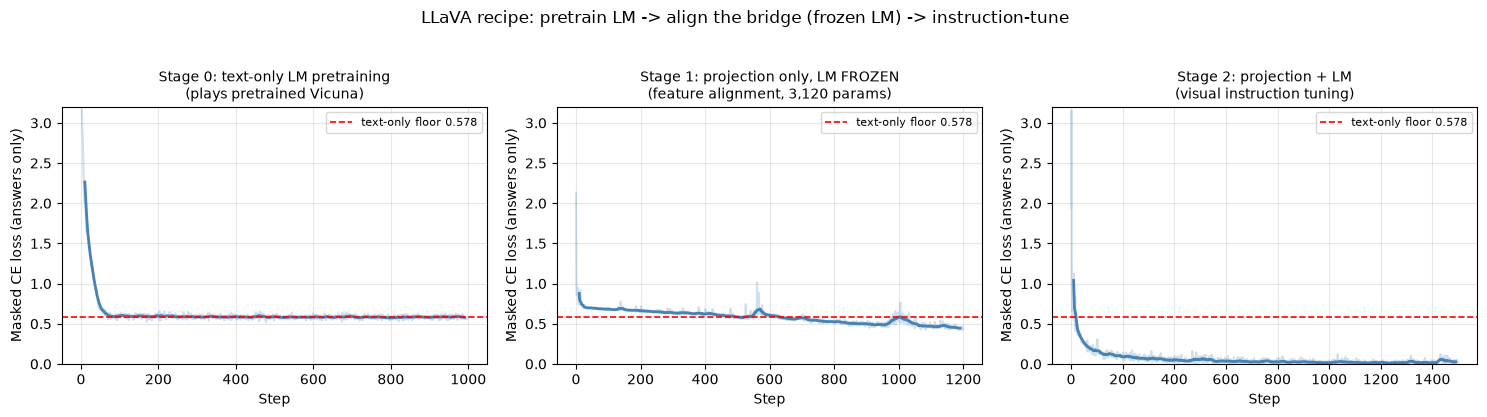

Stage 0 final ~0.583 (floor 0.578) | Stage 1 final ~0.452 | Stage 2 final ~0.030


In [10]:
def smooth(x, w=20):
    """Moving average for plotting"""
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, hist, title in zip(
        axes, [s0_hist, s1_hist, s2_hist],
        ['Stage 0: text-only LM pretraining\n(plays pretrained Vicuna)',
         'Stage 1: projection only, LM FROZEN\n(feature alignment, 3,120 params)',
         'Stage 2: projection + LM\n(visual instruction tuning)']):
    ax.plot(hist, alpha=0.25, color='steelblue')
    ax.plot(np.arange(len(smooth(hist))) + 10, smooth(hist), color='steelblue', lw=2)
    # 纯文本信息论下限:跌破它=视觉信息开始流入语言模型
    ax.axhline(FLOOR0, color='red', ls='--', lw=1.2, label=f'text-only floor {FLOOR0:.3f}')
    ax.set_xlabel('Step'); ax.set_ylabel('Masked CE loss (answers only)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 3.2)
plt.suptitle('LLaVA recipe: pretrain LM -> align the bridge (frozen LM) -> instruction-tune', y=1.03)
plt.tight_layout(); plt.show()
print(f'Stage 0 final ~{np.mean(s0_hist[-50:]):.3f} (floor {FLOOR0:.3f}) | '
      f'Stage 1 final ~{np.mean(s1_hist[-50:]):.3f} | Stage 2 final ~{np.mean(s2_hist[-50:]):.3f}')

## Generation & Evaluation(生成与评估)

#### 💻 代码解读

**做什么:** 实现贪心解码和严格评估:在 300 张全新测试图上,对每类指令随机抽模板提问,**只有生成序列与标准答案逐词完全一致(并正确停在 `<eos>`)才算对**。同时评估完整模型和 Stage-1 基线。

**怎么做:**
- `generate`:图像特征过投影得视觉 token,文本从 `<bos>+指令` 出发,每步取 argmax、遇 `<eos>` 停——标准自回归贪心解码。
- 严格评分照顾"指令跟随"的本义:基线模型答"one red circle"即使包含正确颜色也判错,因为它没有**只**回答被问的问题;辅以宽松指标 contains(答案词是否出现在生成中)来区分"没看见"和"没听话"。
- 两个模型用同一个 `default_rng(7)` 评估,保证问的是完全相同的问题。
- 打印几条样例生成,直观感受基线"自说自话" vs 完整模型"问什么答什么"。

In [11]:
def generate(lm_p, proj_p, feat, instr, max_new=5):
    """Greedy decode: visual tokens + <bos> + instruction -> answer tokens"""
    vis = (feat @ proj_p['Wp'] + proj_p['bp'])[None]
    toks = [BOS] + [W2I[w] for w in instr]
    out = []
    for _ in range(max_new):
        X = np.array([toks])
        logits, _ = lm_forward(lm_p, vis, X)
        nxt = int(logits[0, -1].argmax())   # 贪心:取最后位置的argmax
        if nxt == EOS:
            break
        out.append(nxt)
        toks.append(nxt)
    return [VOCAB[t] for t in out]

def evaluate(lm_p, proj_p, F, attrs, rng):
    """Strict exact-match accuracy per instruction type + lenient 'contains' rate"""
    accs, contains = {}, {}
    for t in QTYPES:
        ok = cont = 0
        for i in range(len(F)):
            tmpl = TEMPLATES[t][rng.integers(len(TEMPLATES[t]))]
            ans = answer_of(t, *attrs[i])
            gen = generate(lm_p, proj_p, F[i], tmpl)
            ok += (gen == ans)           # 严格:逐词全对且正确停机
            cont += (ans[0] in gen)      # 宽松:答案词出现即可
        accs[t] = ok / len(F)
        contains[t] = cont / len(F)
    return accs, contains

# 两个模型用同一rng(7)评估,问的是完全相同的问题
acc_full, cont_full = evaluate(lm, proj, Fte, attr_te, np.random.default_rng(7))
acc_base, cont_base = evaluate(lm_s1, proj_s1, Fte, attr_te, np.random.default_rng(7))

# 描述能力(无rng):与真实caption逐词比对
cap_base = np.mean([generate(lm_s1, proj_s1, Fte[i], DESCRIBE) == caption_of(*attr_te[i]) for i in range(len(Fte))])
cap_full = np.mean([generate(lm, proj, Fte[i], DESCRIBE) == caption_of(*attr_te[i]) for i in range(len(Fte))])

print('=== exact-match accuracy on 300 unseen test images ===')
print(f'{"":>22s}  color   shape   count   describe')
print(f'{"FULL (two-stage)":>22s}  {acc_full["color"]:.3f}   {acc_full["shape"]:.3f}   {acc_full["count"]:.3f}   {cap_full:.3f}')
print(f'{"BASE (skip Stage 2)":>22s}  {acc_base["color"]:.3f}   {acc_base["shape"]:.3f}   {acc_base["count"]:.3f}   {cap_base:.3f}')
print(f'{"BASE contains-answer":>22s}  {cont_base["color"]:.3f}   {cont_base["shape"]:.3f}   {cont_base["count"]:.3f}     -')
print()
print('--- sample generations (Q -> answer) ---')
for i in range(3):
    c, s, k = attr_te[i]
    print(f'image #{i}: {NUMW[k]} {c} {s}')
    for t in QTYPES:
        tmpl = TEMPLATES[t][0]
        print(f'   full: {" ".join(tmpl):<28s} -> {" ".join(generate(lm, proj, Fte[i], tmpl))}')
        print(f'   base: {" ".join(tmpl):<28s} -> {" ".join(generate(lm_s1, proj_s1, Fte[i], tmpl))}')

=== exact-match accuracy on 300 unseen test images ===
                        color   shape   count   describe
      FULL (two-stage)  0.997   0.933   0.987   0.920
   BASE (skip Stage 2)  0.313   0.017   0.687   0.567
  BASE contains-answer  0.663   0.230   0.923     -

--- sample generations (Q -> answer) ---
image #0: two green circle
   full: what color is the shape      -> green
   base: what color is the shape      -> green
   full: what shape is it             -> circle
   base: what shape is it             -> two green
   full: how many shapes are there    -> two
   base: how many shapes are there    -> two
image #1: two green square
   full: what color is the shape      -> green
   base: what color is the shape      -> green
   full: what shape is it             -> square
   base: what shape is it             -> two green
   full: how many shapes are there    -> two
   base: how many shapes are there    -> two
image #2: one red triangle
   full: what color is the shape      -

## The Signature Demo: One Image, Different Instructions(招牌实验:同一张图,问什么答什么)

#### 💻 代码解读

**做什么:** LLaVA 的招牌能力可视化——网格图:每行一张测试图,四列分别问颜色、形状、数量和要求描述,展示完整两阶段模型的回答;绿色=正确。

**怎么做:**
- 从测试集中确定性地挑 3 张属性各异的图(先找 1 物体、再找 2 物体、再找颜色不同的第三张),不消耗随机流。
- 每个问答格子用 `ax.text` 渲染 "Q: … / A: …",`ax.axis('off')` 去掉坐标轴;答案与真值比对后上色。
- 同一张图、同一套权重,仅仅换一句指令,输出就从颜色词切换到形状词/数量词——**指令在运行时"选择"了视觉信息的哪一部分被说出来**,这就是视觉指令微调的全部意义。

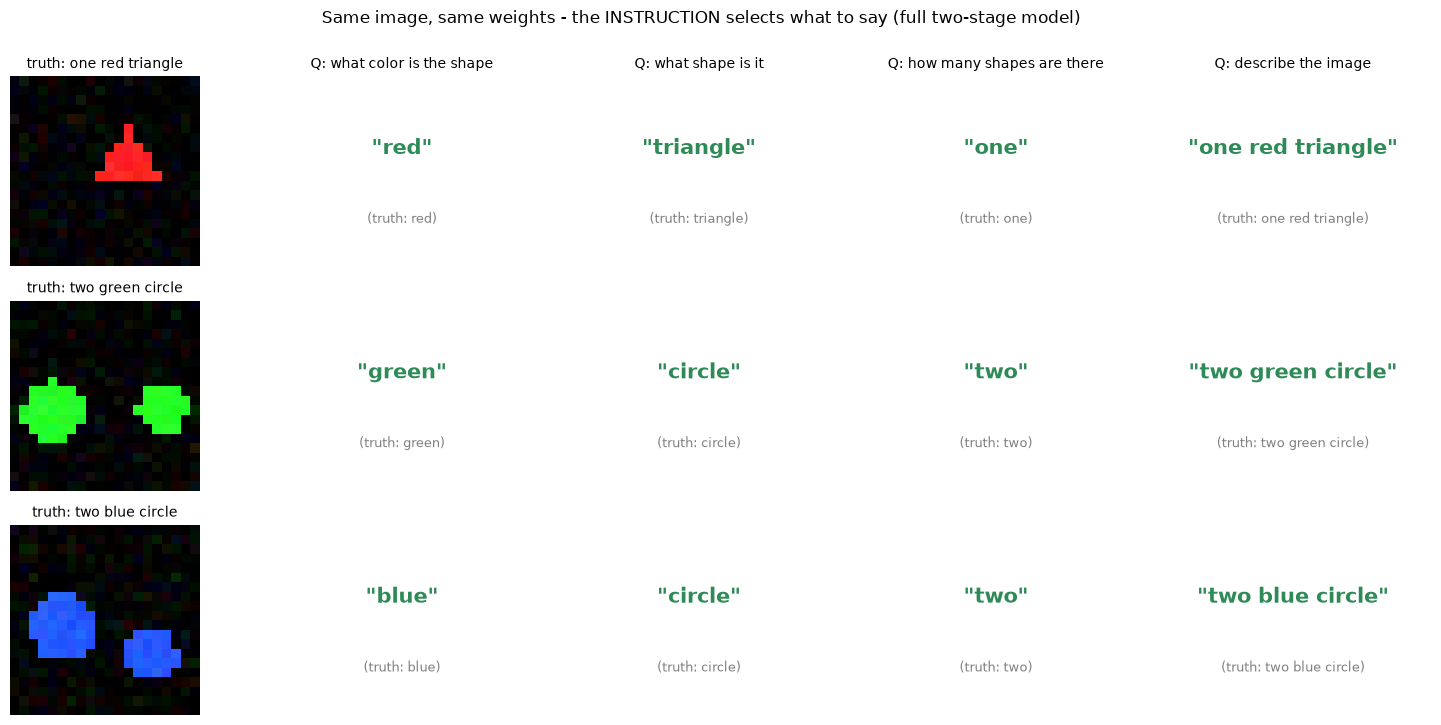

In [12]:
# 确定性挑3张属性各异的测试图:1物体、2物体、颜色不同的第三张
i_a = next(i for i in range(len(attr_te)) if attr_te[i][2] == 1)
i_b = next(i for i in range(len(attr_te)) if attr_te[i][2] == 2)
i_c = next(i for i in range(len(attr_te)) if attr_te[i][0] not in (attr_te[i_a][0], attr_te[i_b][0]))
show_idx = [i_a, i_b, i_c]

fig, axes = plt.subplots(3, 5, figsize=(15, 7.2))
col_titles = ['image', 'Q: what color is the shape', 'Q: what shape is it',
              'Q: how many shapes are there', 'Q: describe the image']
for row, ti in enumerate(show_idx):
    c, s, k = attr_te[ti]
    axes[row, 0].imshow(Xte[ti].reshape(2, 2, IMG//2, IMG//2, 3).transpose(0, 2, 1, 3, 4).reshape(IMG, IMG, 3))
    axes[row, 0].set_title(f'truth: {NUMW[k]} {c} {s}', fontsize=10)
    axes[row, 0].axis('off')
    tasks = [(TEMPLATES['color'][0], answer_of('color', c, s, k)),
             (TEMPLATES['shape'][0], answer_of('shape', c, s, k)),
             (TEMPLATES['count'][0], answer_of('count', c, s, k)),
             (DESCRIBE, caption_of(c, s, k))]
    for col, (instr, truth) in enumerate(tasks, start=1):
        gen = generate(lm, proj, Fte[ti], instr)
        okc = 'seagreen' if gen == truth else 'firebrick'
        ax = axes[row, col]
        ax.text(0.5, 0.62, '"' + ' '.join(gen) + '"', ha='center', va='center',
                fontsize=15, weight='bold', color=okc, transform=ax.transAxes)
        ax.text(0.5, 0.25, '(truth: ' + ' '.join(truth) + ')', ha='center', va='center',
                fontsize=9, color='gray', transform=ax.transAxes)
        ax.axis('off')
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontsize=10) if col > 0 else None
plt.suptitle('Same image, same weights - the INSTRUCTION selects what to say (full two-stage model)', y=1.0)
plt.tight_layout(); plt.show()

## Ablation: Skipping Stage 2(基线对比:跳过 Stage 2 的模型只会"自说自话")

#### 💻 代码解读

**做什么:** 按指令类型分组的准确率柱状图:完整两阶段模型 vs 跳过 Stage 2 的基线,并叠加基线的 contains-answer(宽松)指标。

**怎么做:**
- 4 组(颜色/形状/数量/描述)× 2 根柱(基线、完整);基线的宽松命中率画成横线小标记,揭示"信息在,但不听话"。
- 灰色虚线是各任务的随机猜测水平(颜色/形状 1/3,数量 1/2,描述 1/18)。
- 读图:完整模型四项全部 ≥92%;基线只有描述像样(57%),形状问题几乎全灭(1.7%)——但它生成里**包含**正确数量词的比例高达 92%。**Stage 2 教的不是感知,是服从。**

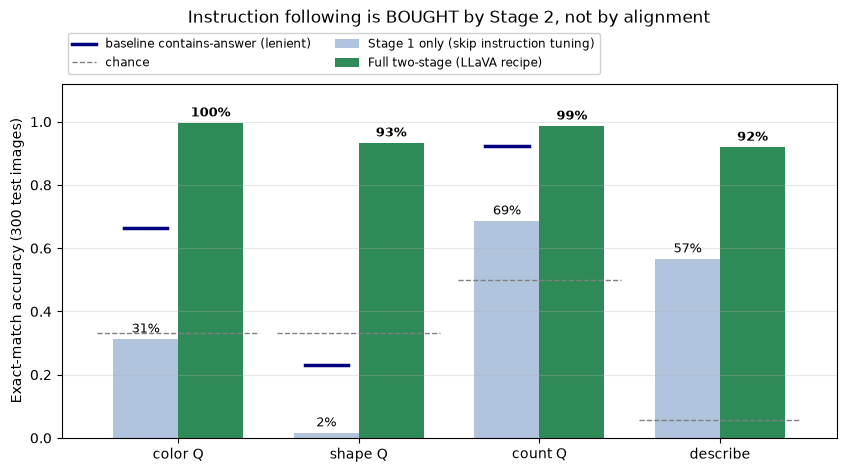

In [13]:
groups = ['color', 'shape', 'count', 'describe']
full_vals = [acc_full['color'], acc_full['shape'], acc_full['count'], cap_full]
base_vals = [acc_base['color'], acc_base['shape'], acc_base['count'], cap_base]
base_cont = [cont_base['color'], cont_base['shape'], cont_base['count'], None]
chance = [1/3, 1/3, 1/2, 1/18]

x = np.arange(4)
w = 0.36
plt.figure(figsize=(10, 4.6))
plt.bar(x - w/2, base_vals, w, color='lightsteelblue', label='Stage 1 only (skip instruction tuning)')
plt.bar(x + w/2, full_vals, w, color='seagreen', label='Full two-stage (LLaVA recipe)')
for i in range(4):
    # 灰色虚线段:该任务的随机猜测水平
    plt.plot([x[i]-0.45, x[i]+0.45], [chance[i]]*2, color='gray', ls='--', lw=1)
    if base_cont[i] is not None:
        # 基线的宽松指标:答案词出现在生成中的比例("信息在,但不听话")
        plt.plot([x[i]-w/2-0.12, x[i]-w/2+0.12], [base_cont[i]]*2, color='navy', lw=2.5)
    plt.text(x[i]+w/2, full_vals[i]+0.02, f'{full_vals[i]:.0%}', ha='center', fontsize=9, weight='bold')
    plt.text(x[i]-w/2, base_vals[i]+0.02, f'{base_vals[i]:.0%}', ha='center', fontsize=9)
plt.plot([], [], color='navy', lw=2.5, label='baseline contains-answer (lenient)')
plt.plot([], [], color='gray', ls='--', lw=1, label='chance')
plt.xticks(x, ['color Q', 'shape Q', 'count Q', 'describe'])
plt.ylabel('Exact-match accuracy (300 test images)')
plt.title('Instruction following is BOUGHT by Stage 2, not by alignment', pad=44)
# 图例放到坐标区上方,避免遮挡接近100%的柱顶标签
plt.ylim(0, 1.12)
plt.legend(fontsize=8.5, loc='lower left', bbox_to_anchor=(0, 1.01), ncol=2, framealpha=0.9)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Mechanism: Where Does the Model Look When Answering?(机制可视化:回答时注意力看向哪里)

#### 💻 代码解读

**做什么:** 打开黑箱:取一张 2 物体测试图,分别问三类问题,提取"即将生成答案的那个位置"在第 2 层对输入序列的注意力分布,并把落在 4 个视觉 token 上的权重画回 2×2 的 patch 网格。

**怎么做:**
- `lm_forward_with_attn` 复用前向代码,额外返回每层的注意力矩阵 A;答案由最后一个指令 token 的位置预测,取该行注意力。
- 结果:第 2 层里该位置把 **≈100%** 的注意力质量投向视觉 token(而不是指令文本)——指令内容在第 1 层已被汇聚,第 2 层专职"读图"。
- 注意力分布随问题变化:颜色/数量问题几乎锁定单个含物体的 patch,形状问题把权重分摊到左右两个物体所在的 patch 上;高权重 patch 与图形位置吻合——模型的回答确实建立在"看"的基础上。
- 视觉 token 权重和(printed)≈1.0,textual token 几乎分不到注意力:对回答而言,**图像就是上下文里唯一有信息量的部分**——这正与 Paper 30(Lost in the Middle)的"检索式注意力"遥相呼应。

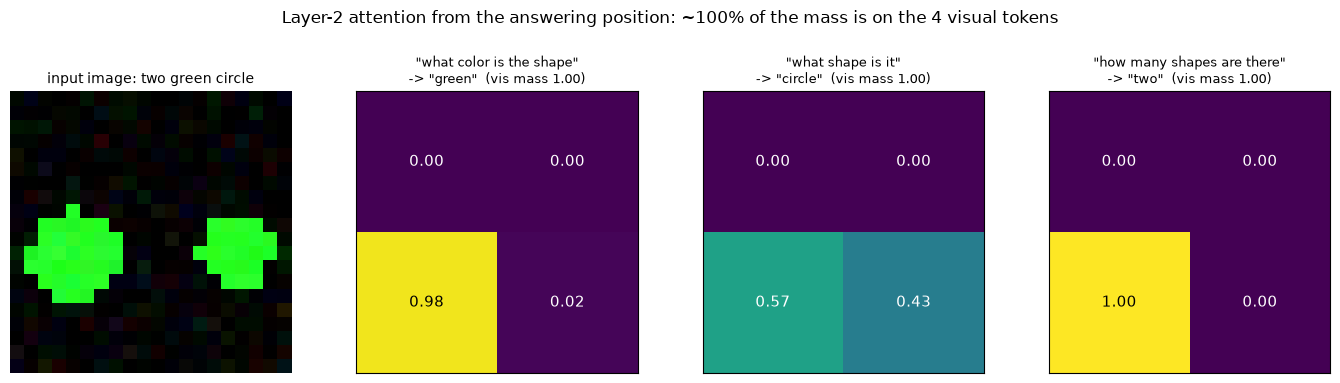

In [14]:
def lm_forward_with_attn(p, vis, X):
    """Same forward pass, but also returns per-layer attention matrices"""
    B, L = X.shape
    P = vis.shape[1]
    T = P + L
    E = np.concatenate([vis, p['Emb'][X]], axis=1) + p['Pos'][:T]
    mask = np.triu(np.full((T, T), -1e9), 1)
    H = E
    attns = []
    for l in range(NL):
        Q = H @ p[f'{l}Wq']; K = H @ p[f'{l}Wk']; Vv = H @ p[f'{l}Wv']
        A = softmax(Q @ K.transpose(0, 2, 1) / np.sqrt(D) + mask)
        attns.append(A)
        H = H + (A @ Vv) @ p[f'{l}Wo']
        U = np.maximum(H @ p[f'{l}W1'] + p[f'{l}b1'], 0)
        H = H + U @ p[f'{l}W2'] + p[f'{l}b2']
    return attns

ti = i_b  # 前面挑好的2物体图像
c, s, k = attr_te[ti]
vis = (Fte[ti] @ proj['Wp'] + proj['bp'])[None]
img_show = Xte[ti].reshape(2, 2, IMG//2, IMG//2, 3).transpose(0, 2, 1, 3, 4).reshape(IMG, IMG, 3)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
axes[0].imshow(img_show)
axes[0].set_title(f'input image: {NUMW[k]} {c} {s}', fontsize=10)
axes[0].axis('off')
for ax, t in zip(axes[1:], QTYPES):
    tmpl = TEMPLATES[t][0]
    X = np.array([[BOS] + [W2I[w] for w in tmpl]])
    attns = lm_forward_with_attn(lm, vis, X)
    # 最后一个指令token的位置即将预测答案:取它在第2层的注意力行
    a_row = attns[-1][0, -1]
    a_vis = a_row[:NVIS]
    im = ax.imshow(a_vis.reshape(2, 2), cmap='viridis', vmin=0, vmax=1)
    for pi in range(2):
        for pj in range(2):
            v = a_vis.reshape(2, 2)[pi, pj]
            ax.text(pj, pi, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.6 else 'black', fontsize=11)
    ans = generate(lm, proj, Fte[ti], tmpl)
    ax.set_title(f'"{" ".join(tmpl)}"\n-> "{" ".join(ans)}"  (vis mass {a_vis.sum():.2f})', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Layer-2 attention from the answering position: ~100% of the mass is on the 4 visual tokens', y=1.05)
plt.tight_layout(); plt.show()

## Key Takeaways(要点总结)

**English:**

1. **The bridge is just a linear layer**: 3,120 projection parameters connect a frozen vision encoder to the LM, and the full model answers color/shape/count instructions at 99.7% / 93.3% / 98.7% — both sides already "speak their own language"; the bridge only translates
2. **Two stages do two different jobs**: Stage 1 (frozen LM, caption task) wires vision into language — the loss drops below the text-only information floor (0.578); Stage 2 (instruction tuning) teaches the model to obey — loss falls from ~0.45 to ~0.03
3. **Seeing is not obeying**: the Stage-1-only baseline contains the right information (count word present 92.3% of the time) yet scores 1.7% on shape questions — it describes no matter what you ask; instruction data buys obedience
4. **Loss floors localize information sources**: text-only pretraining plateaus exactly at its entropy floor; the moment training loss dips below it, visual information is flowing into the LM
5. **Attention shows the mechanism**: the answering position devotes ~100% of its layer-2 attention to the 4 visual tokens, on different patches for different questions
6. **Diversity and mixing matter**: multiple templates per instruction type force semantic mapping instead of memorization, and mixing 25% description data into Stage 2 prevents catastrophic forgetting (describe: 92.0% vs the QA-only failure mode)

**中文:**

1. **桥只是一个线性层**:3,120 个投影参数连接冻结的视觉编码器与 LM,完整模型三类指令准确率 99.7% / 93.3% / 98.7%——两端都已"会说自己的语言",桥只负责翻译
2. **两阶段各司其职**:Stage 1(冻结 LM,描述任务)把视觉接入语言——损失跌破纯文本信息下限 0.578;Stage 2(指令微调)教会服从——损失从 ~0.45 降到 ~0.03
3. **会看≠听话**:只做 Stage 1 的基线,生成里包含正确信息(数量词命中 92.3%),形状问题却只有 1.7%——问什么都答描述;服从是指令数据买来的
4. **损失下限定位信息来源**:纯文本预训练恰好停在熵下限;损失跌破下限的那一刻,就是视觉信息流入 LM 的时刻
5. **注意力揭示机制**:回答位置在第 2 层把 ≈100% 注意力投给 4 个视觉 token,不同问题看不同 patch
6. **多样性与混合很重要**:每类指令多模板迫使模型学语义映射而非背句子;Stage 2 混入 25% 描述数据以保留描述能力(描述 92.0%;防遗忘是设计动机,本文未做消融验证)

**与本仓库其他论文的联系:** 视觉编码器的角色由 CLIP(Bonus 31)扮演,其前身是 AlexNet/ResNet(Papers 7/10/15);LM 是 Paper 13(Transformer)的因果解码器,自回归生成与 Paper 2(char-RNN)同源;"损失只算回答、指令被掩掉"的做法与 Paper 21(CTC)一样体现"对齐目标决定学到什么";冻结主干、只训小接口的思想与 Paper 5(剪枝)和 GPipe(Paper 9)的"参数效率"一脉相承;而"回答位置的检索式注意力"呼应 Paper 30(Lost in the Middle)。LLaVA = CLIP 的眼睛 + Transformer 的嘴 + 指令数据的教养。